In [1]:
import numpy as np
import pandas as pd

In [2]:
stations = {
    'Adamstown': 1,
    'Broadmeadow': 3,
    'Dora Creek': 8,
    'Maryland': 12,
    'Mayfield': 13,
    'Merewether Hts': 15,
    'Shortland 1': 18,
    'Swansea 8': 20,
    'Teralba 1': 22,
    'Wallsend': 25,
    'Wangi Wangi': 26,
    'Waratah': 27,
}   

In [3]:
def read_data(station):
    """Read data for a particular weather station"""

    station_number = stations[station]
    df = pd.read_csv('hunter_water_corporation.csv', skiprows=1)
    station_df = df[[f'Time.{station_number}', f'Value.{station_number}']]
    station_df = station_df.rename(columns={f'Time.{station_number}': 'time', f'Value.{station_number}': 'rainfall (mm)'})
    station_df['time'] = pd.to_datetime(station_df['time'], format='mixed', dayfirst=True)
    station_df = station_df.set_index('time')
    diff = station_df['rainfall (mm)'].values[1:] - station_df['rainfall (mm)'].values[:-1]
    diff = np.clip(diff, a_min=0, a_max=None)
    station_df['rainfall (mm)'].values[1:] = diff

    return station_df

In [5]:
def get_max(station_df, tscale, plot=False):
    """Get the maximum value."""
    
    station_df_5min = station_df.resample('5min').sum()
    if plot:
        station_df_5min.loc['2007-06-08': '2007-06-09'].plot()
    rolling_sum_hr = station_df_5min.rolling(window=tscale).sum()
    if plot:
        rolling_sum_hr.loc['2007-06-08': '2007-06-09'].plot()
    max_index = rolling_sum_hr['rainfall (mm)'].argmax()
    print(rolling_sum_hr.iloc[max_index])

In [6]:
station_df = read_data('Adamstown')

rainfall (mm)    93.2
Name: 2007-06-08 18:15:00, dtype: float64


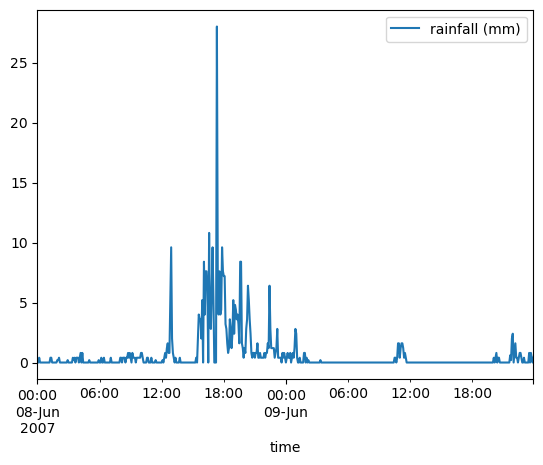

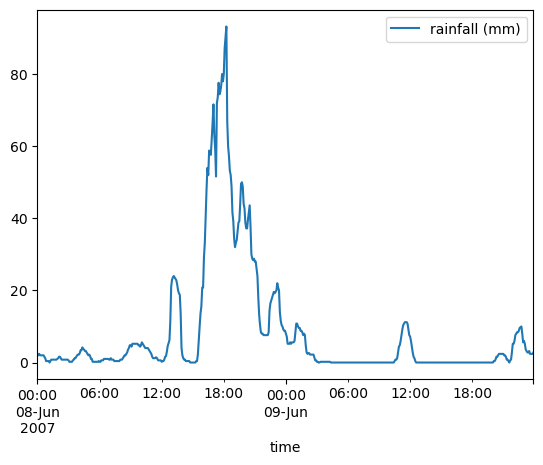

In [7]:
get_max(station_df, '1h', plot=True)

In [8]:
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    93.2
Name: 2007-06-08 18:15:00, dtype: float64
2h
rainfall (mm)    151.6
Name: 2007-06-08 18:00:00, dtype: float64
3h
rainfall (mm)    187.6
Name: 2007-06-08 18:25:00, dtype: float64
6h
rainfall (mm)    281.2
Name: 2007-06-08 21:25:00, dtype: float64
12h
rainfall (mm)    338.8
Name: 2007-06-09 00:15:00, dtype: float64
24h
rainfall (mm)    370.4
Name: 2007-06-09 01:50:00, dtype: float64


In [9]:
station_df = read_data('Broadmeadow')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    69.2
Name: 2007-06-08 18:15:00, dtype: float64
2h
rainfall (mm)    100.0
Name: 2007-06-08 19:15:00, dtype: float64
3h
rainfall (mm)    138.8
Name: 2007-06-08 18:45:00, dtype: float64
6h
rainfall (mm)    203.4
Name: 2007-06-08 21:25:00, dtype: float64
12h
rainfall (mm)    247.2
Name: 2007-06-09 00:15:00, dtype: float64
24h
rainfall (mm)    267.2
Name: 2007-06-09 11:40:00, dtype: float64


In [10]:
station_df = read_data('Dora Creek')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    44.0
Name: 2007-06-08 18:40:00, dtype: float64
2h
rainfall (mm)    60.4
Name: 2007-06-08 18:40:00, dtype: float64
3h
rainfall (mm)    81.0
Name: 2007-06-08 18:40:00, dtype: float64
6h
rainfall (mm)    121.4
Name: 2007-06-08 20:35:00, dtype: float64
12h
rainfall (mm)    153.6
Name: 2007-06-08 23:55:00, dtype: float64
24h
rainfall (mm)    214.4
Name: 2007-06-09 05:45:00, dtype: float64


In [11]:
station_df = read_data('Maryland')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    61.2
Name: 2007-06-08 13:15:00, dtype: float64
2h
rainfall (mm)    62.0
Name: 2007-06-08 13:15:00, dtype: float64
3h
rainfall (mm)    71.2
Name: 2007-06-08 18:55:00, dtype: float64
6h
rainfall (mm)    119.2
Name: 2007-06-08 21:35:00, dtype: float64
12h
rainfall (mm)    212.8
Name: 2007-06-09 00:15:00, dtype: float64
24h
rainfall (mm)    253.0
Name: 2007-06-09 01:20:00, dtype: float64


In [12]:
station_df = read_data('Mayfield')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    44.2
Name: 2007-06-08 13:05:00, dtype: float64
2h
rainfall (mm)    65.6
Name: 2007-06-08 17:30:00, dtype: float64
3h
rainfall (mm)    86.4
Name: 2007-06-08 18:30:00, dtype: float64
6h
rainfall (mm)    147.4
Name: 2007-06-08 21:20:00, dtype: float64
12h
rainfall (mm)    210.0
Name: 2007-06-09 00:10:00, dtype: float64
24h
rainfall (mm)    230.6
Name: 2007-06-09 11:50:00, dtype: float64


In [13]:
station_df = read_data('Merewether Hts')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    78.4
Name: 2007-06-08 17:00:00, dtype: float64
2h
rainfall (mm)    143.6
Name: 2007-06-08 18:00:00, dtype: float64
3h
rainfall (mm)    192.0
Name: 2007-06-08 18:20:00, dtype: float64
6h
rainfall (mm)    279.0
Name: 2007-06-08 21:20:00, dtype: float64
12h
rainfall (mm)    322.4
Name: 2007-06-09 00:45:00, dtype: float64
24h
rainfall (mm)    345.0
Name: 2007-06-09 01:00:00, dtype: float64


In [14]:
station_df = read_data('Shortland 1')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    57.6
Name: 2007-06-08 13:10:00, dtype: float64
2h
rainfall (mm)    58.0
Name: 2007-06-08 13:10:00, dtype: float64
3h
rainfall (mm)    59.2
Name: 2007-06-08 13:10:00, dtype: float64
6h
rainfall (mm)    101.6
Name: 2007-06-08 18:15:00, dtype: float64
12h
rainfall (mm)    163.2
Name: 2007-06-09 00:10:00, dtype: float64
24h
rainfall (mm)    193.2
Name: 2007-06-09 05:55:00, dtype: float64


In [15]:
station_df = read_data('Swansea 8')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    32.4
Name: 2007-06-08 16:15:00, dtype: float64
2h
rainfall (mm)    46.6
Name: 2007-06-08 16:20:00, dtype: float64
3h
rainfall (mm)    56.6
Name: 2007-06-08 16:00:00, dtype: float64
6h
rainfall (mm)    85.2
Name: 2007-06-08 18:55:00, dtype: float64
12h
rainfall (mm)    149.8
Name: 2007-06-09 00:35:00, dtype: float64
24h
rainfall (mm)    180.2
Name: 2007-06-09 01:25:00, dtype: float64


In [16]:
station_df = read_data('Teralba 1')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    50.4
Name: 2007-06-08 20:45:00, dtype: float64
2h
rainfall (mm)    86.0
Name: 2007-06-08 20:45:00, dtype: float64
3h
rainfall (mm)    110.8
Name: 2007-06-08 20:45:00, dtype: float64
6h
rainfall (mm)    187.8
Name: 2007-06-08 21:15:00, dtype: float64
12h
rainfall (mm)    230.2
Name: 2007-06-09 00:20:00, dtype: float64
24h
rainfall (mm)    240.0
Name: 2007-06-08 23:50:00, dtype: float64


In [17]:
station_df = read_data('Wallsend')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    56.4
Name: 2007-06-08 20:25:00, dtype: float64
2h
rainfall (mm)    94.8
Name: 2007-06-08 20:05:00, dtype: float64
3h
rainfall (mm)    120.0
Name: 2007-06-08 21:05:00, dtype: float64
6h
rainfall (mm)    171.6
Name: 2007-06-08 21:35:00, dtype: float64
12h
rainfall (mm)    252.0
Name: 2007-06-09 00:35:00, dtype: float64
24h
rainfall (mm)    299.2
Name: 2007-06-09 02:05:00, dtype: float64


In [18]:
station_df = read_data('Wangi Wangi')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    39.2
Name: 2007-06-08 18:30:00, dtype: float64
2h
rainfall (mm)    70.0
Name: 2007-06-08 18:05:00, dtype: float64
3h
rainfall (mm)    85.2
Name: 2007-06-08 18:45:00, dtype: float64
6h
rainfall (mm)    120.2
Name: 2007-06-08 19:00:00, dtype: float64
12h
rainfall (mm)    171.8
Name: 2007-06-09 00:45:00, dtype: float64
24h
rainfall (mm)    191.4
Name: 2007-06-09 01:30:00, dtype: float64


In [19]:
station_df = read_data('Waratah')
for tscale in ['1h', '2h', '3h', '6h', '12h', '24h']:
    print(tscale)
    get_max(station_df, tscale)

1h
rainfall (mm)    47.4
Name: 2007-06-08 13:10:00, dtype: float64
2h
rainfall (mm)    62.2
Name: 2007-06-08 19:40:00, dtype: float64
3h
rainfall (mm)    86.2
Name: 2007-06-08 18:55:00, dtype: float64
6h
rainfall (mm)    148.8
Name: 2007-06-08 21:25:00, dtype: float64
12h
rainfall (mm)    223.2
Name: 2007-06-09 00:20:00, dtype: float64
24h
rainfall (mm)    254.0
Name: 2007-06-09 02:00:00, dtype: float64
